# Micro Proyecto 3 — Fine-tuning de Llama-3.2-1B con LoRA

**Curso:** Modelos Avanzados para el Procesamiento de Lenguaje Natural  
**Universidad de Los Andes**

---

**Objetivo:** Realizar fine-tuning del modelo `Llama-3.2-1B` mediante LoRA para resolver preguntas de selección múltiple del dataset RACE, y comparar el accuracy del modelo original vs. el modelo ajustado.

**Estructura del notebook:**
1. Instalación y configuración
2. Carga y exploración del dataset RACE
3. Carga del modelo base Llama-3.2-1B
4. Evaluación del modelo base (pre fine-tuning)
5. Preparación de datos para fine-tuning
6. Fine-tuning con LoRA
7. Evaluación del modelo ajustado (post fine-tuning)
8. Comparación de resultados
9. Guardado del checkpoint

## 1. Instalación y Configuración

In [1]:
!pip install -q transformers datasets peft accelerate matplotlib

In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import copy

# Dispositivo: CUDA para Colab GPU, MPS para Mac M2, o CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Dispositivo: {device}")
print(f"PyTorch version: {torch.__version__}")

Dispositivo: cuda
PyTorch version: 2.10.0+cu128


## 2. Carga y Exploración del Dataset RACE

El dataset RACE contiene ~100k preguntas de comprensión lectora con 4 opciones de respuesta. Filtramos únicamente los ejemplos cuyo artículo tenga **menos de 800 caracteres** (`len(article) < 800`).

In [4]:
# Cargar dataset RACE (all = middle + high)
dataset = load_dataset("ehovy/race", "all")

# Filtrar ejemplos con artículos < 800 caracteres
train_data = dataset["train"].filter(lambda x: len(x["article"]) < 800)
test_data = dataset["test"].filter(lambda x: len(x["article"]) < 800)

print(f"Ejemplos de entrenamiento (filtrados): {len(train_data)}")
print(f"Ejemplos de evaluación (filtrados):    {len(test_data)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

all/train-00000-of-00001.parquet:   0%|          | 0.00/37.4M [00:00<?, ?B/s]

all/validation-00000-of-00001.parquet:   0%|          | 0.00/2.05M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/87866 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4887 [00:00<?, ? examples/s]

Filter:   0%|          | 0/87866 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4934 [00:00<?, ? examples/s]

Ejemplos de entrenamiento (filtrados): 8930
Ejemplos de evaluación (filtrados):    480


In [5]:
# Explorar un ejemplo del dataset
example = train_data[0]
print("=== Ejemplo del dataset ===")
print(f"Artículo:\n{example['article']}\n")
print(f"Pregunta: {example['question']}")
print(f"Opciones: {example['options']}")
print(f"Respuesta correcta: {example['answer']}")
print(f"Longitud del artículo: {len(example['article'])} caracteres")

=== Ejemplo del dataset ===
Artículo:
The air hostess   was in a small kitchen at the back of the plane, preparing the plates for lunch, when a little old lady came and spoke to her, "Could you please tell me," she asked, "where is the ladies' lavatory   in the plane?"
"Yes, madam," said the air hostess and smiled. "It is right at the other end of the plane---at the front."
The little lady went too far. She walked all the way to the front of the plane, opened the door in front of her, and saw the captain of the plane and the other officers. They were all busy with their work and did not see her. She went out again, shut the door and returned to the air hostess.
"Oh, didn't you find it, madam?" the girl asked her. "Yes, I did," said the little lady. "But there are four men in the ladies' lavatory watching television."

Pregunta: The story happened  _  .
Opciones: ['in the evening', 'in the afternoon', 'in the morning', 'at midnight']
Respuesta correcta: C
Longitud del artículo: 790 cara

## 3. Carga del Modelo Base Llama-3.2-1B

In [6]:
MODEL_NAME = "unsloth/Llama-3.2-1B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)

# Configurar pad token (Llama no tiene uno por defecto)
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros del modelo: {total_params / 1e9:.2f}B")

config.json:   0%|          | 0.00/889 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

Parámetros del modelo: 1.24B


## 4. Evaluación del Modelo Base (Pre Fine-tuning)

Para evaluar, calculamos la **log-probabilidad** de cada opción de respuesta dado el contexto (artículo + pregunta). La respuesta seleccionada es la que tiene mayor probabilidad:

$$\text{Respuesta} = \arg\max_{s \in S} P(s|c), \quad P(s|c) = \prod_{i=1}^{n} P(s_i | s_{i-1}..s_1, c)$$

Usamos log-probabilidades para evitar underflow numérico.

In [7]:
def build_prompt(article, question):
    """Construye el prompt con el artículo y la pregunta."""
    return (
        f"Read the following article and answer the question.\n\n"
        f"Article: {article}\n\n"
        f"Question: {question}\n\n"
        f"Answer:"
    )


def compute_log_prob(model, tokenizer, context_text, answer_text, device):
    """
    Calcula la log-probabilidad normalizada de 'answer_text' dado 'context_text'.
    Se normaliza dividiendo entre el número de tokens de la respuesta para evitar
    sesgo hacia respuestas más cortas.
    """
    context_ids = tokenizer.encode(context_text, add_special_tokens=False)
    answer_ids = tokenizer.encode(" " + answer_text, add_special_tokens=False)

    input_ids = torch.tensor([context_ids + answer_ids], device=device)

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits

    log_probs = F.log_softmax(logits, dim=-1)

    total_log_prob = 0.0
    start = len(context_ids)

    for i in range(len(answer_ids)):
        token_id = input_ids[0, start + i]
        total_log_prob += log_probs[0, start + i - 1, token_id].item()

    # Normalizar por longitud de la respuesta para no sesgar hacia respuestas cortas
    normalized_log_prob = total_log_prob / len(answer_ids)

    return normalized_log_prob

In [8]:
def evaluate_model(model, tokenizer, eval_data, device):
    """
    Evalúa el modelo en el dataset calculando accuracy.
    Para cada pregunta, selecciona la opción con mayor log-probabilidad.
    """
    label_map = {"A": 0, "B": 1, "C": 2, "D": 3}
    correct = 0
    total = len(eval_data)

    for i in tqdm(range(total), desc="Evaluando"):
        example = eval_data[i]
        prompt = build_prompt(example["article"], example["question"])
        options = example["options"]
        correct_idx = label_map[example["answer"]]

        # Calcular log-prob de cada opción
        log_probs = []
        for option in options:
            lp = compute_log_prob(model, tokenizer, prompt, option, device)
            log_probs.append(lp)

        # Seleccionar la opción con mayor log-probabilidad
        predicted_idx = np.argmax(log_probs)
        if predicted_idx == correct_idx:
            correct += 1

    accuracy = correct / total
    return accuracy

In [9]:
# Evaluar modelo base en el conjunto de test
print("Evaluando modelo base Llama-3.2-1B (sin fine-tuning)...")
base_accuracy = evaluate_model(model, tokenizer, test_data, device)
print(f"\nAccuracy del modelo base: {base_accuracy:.4f} ({base_accuracy*100:.2f}%)")

Evaluando modelo base Llama-3.2-1B (sin fine-tuning)...


Evaluando: 100%|██████████| 480/480 [05:57<00:00,  1.34it/s]


Accuracy del modelo base: 0.5271 (52.71%)


## 5. Preparación de Datos para Fine-tuning

Cada ejemplo de entrenamiento se formatea como: `contexto + respuesta_correcta`.

Los **labels** tienen valor `-100` en los tokens del contexto para que la función de pérdida los ignore, y el modelo solo aprenda a generar la respuesta.

In [10]:
class RACEDataset(Dataset):
    """Dataset para fine-tuning en la tarea de selección múltiple."""

    def __init__(self, data, tokenizer, max_length=512):
        self.examples = []
        self.tokenizer = tokenizer
        self.max_length = max_length
        label_map = {"A": 0, "B": 1, "C": 2, "D": 3}

        for i in range(len(data)):
            item = data[i]
            correct_idx = label_map[item["answer"]]
            correct_answer = item["options"][correct_idx]

            # Construir contexto y respuesta
            context = build_prompt(item["article"], item["question"])
            answer = " " + correct_answer

            self.examples.append((context, answer))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        context, answer = self.examples[idx]

        # Tokenizar contexto y respuesta por separado
        context_ids = self.tokenizer.encode(context, add_special_tokens=False)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)

        # Concatenar y truncar si es necesario
        input_ids = context_ids + answer_ids
        if len(input_ids) > self.max_length:
            # Truncar el contexto, mantener la respuesta completa
            max_context = self.max_length - len(answer_ids)
            context_ids = context_ids[:max_context]
            input_ids = context_ids + answer_ids

        # Labels: -100 para el contexto, token_ids para la respuesta
        labels = [-100] * len(context_ids) + answer_ids

        # Crear attention mask
        attention_mask = [1] * len(input_ids)

        return {
            "input_ids": torch.tensor(input_ids),
            "attention_mask": torch.tensor(attention_mask),
            "labels": torch.tensor(labels),
        }


def collate_fn(batch):
    """Padding dinámico para el batch."""
    max_len = max(len(item["input_ids"]) for item in batch)

    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
        pad_len = max_len - len(item["input_ids"])
        input_ids.append(F.pad(item["input_ids"], (pad_len, 0), value=tokenizer.pad_token_id))
        attention_masks.append(F.pad(item["attention_mask"], (pad_len, 0), value=0))
        labels.append(F.pad(item["labels"], (pad_len, 0), value=-100))

    return {
        "input_ids": torch.stack(input_ids),
        "attention_mask": torch.stack(attention_masks),
        "labels": torch.stack(labels),
    }

In [11]:
# Crear datasets y dataloaders
BATCH_SIZE = 4

train_dataset = RACEDataset(train_data, tokenizer, max_length=512)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

print(f"Ejemplos de entrenamiento: {len(train_dataset)}")
print(f"Batches por época: {len(train_loader)}")

# Verificar un ejemplo
sample = train_dataset[0]
print(f"\nEjemplo de input_ids shape: {sample['input_ids'].shape}")
print(f"Tokens con label -100 (contexto): {(sample['labels'] == -100).sum().item()}")
print(f"Tokens con label real (respuesta): {(sample['labels'] != -100).sum().item()}")

Ejemplos de entrenamiento: 8930
Batches por época: 2233

Ejemplo de input_ids shape: torch.Size([221])
Tokens con label -100 (contexto): 218
Tokens con label real (respuesta): 3


## 6. Fine-tuning con LoRA

Aplicamos **LoRA (Low-Rank Adaptation)** para ajustar el modelo de forma eficiente, entrenando solo una fracción de los parámetros totales.

In [12]:
!pip install -q torchao>=0.16.0 peft --upgrade


In [14]:
# Configuración de LoRA
lora_config = LoraConfig(
    r=8,                        # Rango de la descomposición
    lora_alpha=16,              # Factor de escala
    lora_dropout=0.05,          # Dropout para regularización
    target_modules=["q_proj", "v_proj"],  # Capas a adaptar
    task_type=TaskType.CAUSAL_LM,
)

# Aplicar LoRA al modelo
model_lora = get_peft_model(model, lora_config)
model_lora.print_trainable_parameters()

trainable params: 851,968 || all params: 1,236,666,368 || trainable%: 0.0689


In [15]:
# Hiperparámetros de entrenamiento
NUM_EPOCHS = 3
LEARNING_RATE = 2e-4
WARMUP_STEPS = 50
EVAL_STEPS = 500  # Evaluar cada N pasos (menos frecuente para no frenar el entrenamiento)

optimizer = torch.optim.AdamW(model_lora.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Scheduler con warmup lineal seguido de decaimiento coseno
total_steps = len(train_loader) * NUM_EPOCHS

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / WARMUP_STEPS  # Warmup lineal
    progress = (step - WARMUP_STEPS) / (total_steps - WARMUP_STEPS)
    return 0.5 * (1 + np.cos(np.pi * progress))  # Decaimiento coseno

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Para seguimiento del entrenamiento
train_losses = []
learning_rates = []
eval_accuracies = []
eval_steps_list = []
global_step = 0

print(f"Total de pasos: {total_steps}")
print(f"Warmup: {WARMUP_STEPS} pasos")
print(f"Scheduler: warmup lineal + decaimiento coseno")

Total de pasos: 6699
Warmup: 50 pasos
Scheduler: warmup lineal + decaimiento coseno


In [16]:
# Subconjunto de evaluación para monitoreo durante entrenamiento (más rápido)
eval_subset_size = min(50, len(test_data))
eval_subset = test_data.select(range(eval_subset_size))

print(f"Se usará un subconjunto de {eval_subset_size} ejemplos para monitoreo durante entrenamiento.")
print(f"La evaluación final se hará sobre el conjunto de test completo ({len(test_data)} ejemplos).")

Se usará un subconjunto de 50 ejemplos para monitoreo durante entrenamiento.
La evaluación final se hará sobre el conjunto de test completo (480 ejemplos).


In [17]:
# Loop de entrenamiento
model_lora.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Época {epoch + 1}/{NUM_EPOCHS}")

    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model_lora(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lora.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        # Registro
        train_losses.append(loss.item())
        learning_rates.append(scheduler.get_last_lr()[0])
        epoch_loss += loss.item()
        global_step += 1

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{scheduler.get_last_lr()[0]:.2e}"})

        # Evaluación periódica en subconjunto
        if global_step % EVAL_STEPS == 0:
            model_lora.eval()
            subset_acc = evaluate_model(model_lora, tokenizer, eval_subset, device)
            eval_accuracies.append(subset_acc)
            eval_steps_list.append(global_step)
            print(f"\n  [Paso {global_step}] Accuracy en subconjunto: {subset_acc:.4f}")
            model_lora.train()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Época {epoch + 1} — Loss promedio: {avg_loss:.4f}")

Época 1/3:  22%|██▏       | 500/2233 [11:56<6:21:38, 13.21s/it, loss=1.1405, lr=1.98e-04]


  [Paso 500] Accuracy en subconjunto: 0.4600


Época 1/3:  45%|████▍     | 1000/2233 [23:47<4:32:51, 13.28s/it, loss=1.5786, lr=1.90e-04]


  [Paso 1000] Accuracy en subconjunto: 0.4000


Época 1/3:  67%|██████▋   | 1500/2233 [35:36<2:42:54, 13.34s/it, loss=2.3575, lr=1.77e-04]

...


  [Paso 6000] Accuracy en subconjunto: 0.5200


Época 3/3:  91%|█████████ | 2034/2233 [48:46<44:00, 13.27s/it, loss=0.4782, lr=4.42e-07]


  [Paso 6500] Accuracy en subconjunto: 0.5200


Época 3/3: 100%|██████████| 2233/2233 [53:13<00:00,  1.43s/it, loss=1.8123, lr=0.00e+00]

Época 3 — Loss promedio: 0.9935


## 7. Evaluación del Modelo Ajustado (Post Fine-tuning)

In [18]:
# Evaluar modelo fine-tuned en el conjunto de test completo
# Guardamos las predicciones para el análisis de errores
model_lora.eval()
print("Evaluando modelo fine-tuned en el conjunto de test completo...")

label_map = {"A": 0, "B": 1, "C": 2, "D": 3}
idx_to_label = {0: "A", 1: "B", 2: "C", 3: "D"}

base_preds = []
ft_preds = []
correct_labels = []

for i in tqdm(range(len(test_data)), desc="Evaluando ambos modelos"):
    example = test_data[i]
    prompt = build_prompt(example["article"], example["question"])
    options = example["options"]
    correct_idx = label_map[example["answer"]]
    correct_labels.append(correct_idx)

    # Predicción modelo base (desactivar LoRA)
    model_lora.disable_adapter_layers()
    base_lps = [compute_log_prob(model_lora, tokenizer, prompt, opt, device) for opt in options]
    base_preds.append(np.argmax(base_lps))

    # Predicción modelo fine-tuned (activar LoRA)
    model_lora.enable_adapter_layers()
    ft_lps = [compute_log_prob(model_lora, tokenizer, prompt, opt, device) for opt in options]
    ft_preds.append(np.argmax(ft_lps))

base_accuracy = sum(b == c for b, c in zip(base_preds, correct_labels)) / len(correct_labels)
finetuned_accuracy = sum(f == c for f, c in zip(ft_preds, correct_labels)) / len(correct_labels)

print(f"\nAccuracy modelo base:      {base_accuracy:.4f} ({base_accuracy*100:.2f}%)")
print(f"Accuracy modelo fine-tuned: {finetuned_accuracy:.4f} ({finetuned_accuracy*100:.2f}%)")

Evaluando modelo fine-tuned en el conjunto de test completo...


Evaluando ambos modelos: 100%|██████████| 480/480 [12:04<00:00,  1.51s/it]


Accuracy modelo base:      0.5271 (52.71%)
Accuracy modelo fine-tuned: 0.7000 (70.00%)


## 8. Comparación de Resultados

In [19]:
# Tabla comparativa
print("=" * 50)
print("       COMPARACIÓN DE RESULTADOS")
print("=" * 50)
print(f"{'Modelo':<30} {'Accuracy':>10}")
print("-" * 50)
print(f"{'Llama-3.2-1B (base)':<30} {base_accuracy*100:>9.2f}%")
print(f"{'Llama-3.2-1B (fine-tuned)':<30} {finetuned_accuracy*100:>9.2f}%")
print("-" * 50)
improvement = (finetuned_accuracy - base_accuracy) * 100
print(f"{'Mejora':<30} {improvement:>+9.2f}%")
print("=" * 50)

       COMPARACIÓN DE RESULTADOS
Modelo                           Accuracy
--------------------------------------------------
Llama-3.2-1B (base)                52.71%
Llama-3.2-1B (fine-tuned)          70.00%
--------------------------------------------------
Mejora                            +17.29%


### Análisis de Errores

Analizamos ejemplos concretos donde el fine-tuning corrigió errores del modelo base, y casos donde el modelo fine-tuned aún falla. Esto permite entender qué tipo de preguntas mejora el entrenamiento.

In [20]:
# Casos donde el base falla pero el fine-tuned acierta
fixed = [i for i in range(len(test_data)) if base_preds[i] != correct_labels[i] and ft_preds[i] == correct_labels[i]]

# Casos donde ambos fallan
both_fail = [i for i in range(len(test_data)) if base_preds[i] != correct_labels[i] and ft_preds[i] != correct_labels[i]]

# Casos donde el base acierta pero el fine-tuned falla (regresiones)
regressions = [i for i in range(len(test_data)) if base_preds[i] == correct_labels[i] and ft_preds[i] != correct_labels[i]]

print(f"Errores corregidos por fine-tuning: {len(fixed)}")
print(f"Errores en ambos modelos:           {len(both_fail)}")
print(f"Regresiones (base OK, fine-tuned mal): {len(regressions)}")

# Mostrar ejemplos corregidos por el fine-tuning
print("\n" + "=" * 60)
print("EJEMPLOS CORREGIDOS POR EL FINE-TUNING")
print("=" * 60)

for idx in fixed[:3]:
    ex = test_data[idx]
    correct_idx = label_map[ex["answer"]]
    print(f"\nPregunta: {ex['question']}")
    print(f"Opciones: {ex['options']}")
    print(f"Correcta: {idx_to_label[correct_idx]} — {ex['options'][correct_idx]}")
    print(f"Base eligió: {idx_to_label[base_preds[idx]]} — {ex['options'][base_preds[idx]]}")
    print(f"Fine-tuned eligió: {idx_to_label[ft_preds[idx]]} — {ex['options'][ft_preds[idx]]}")
    print("-" * 60)

# Mostrar regresiones si las hay
if regressions:
    print("\n" + "=" * 60)
    print("REGRESIONES (base acierta, fine-tuned falla)")
    print("=" * 60)
    for idx in regressions[:2]:
        ex = test_data[idx]
        correct_idx = label_map[ex["answer"]]
        print(f"\nPregunta: {ex['question']}")
        print(f"Correcta: {idx_to_label[correct_idx]} — {ex['options'][correct_idx]}")
        print(f"Fine-tuned eligió: {idx_to_label[ft_preds[idx]]} — {ex['options'][ft_preds[idx]]}")
        print("-" * 60)

Errores corregidos por fine-tuning: 102
Errores en ambos modelos:           125
Regresiones (base OK, fine-tuned mal): 19

EJEMPLOS CORREGIDOS POR EL FINE-TUNING

Pregunta: Why does the woman dress her children in the same clothes? Because   _  .
Opciones: ['she has so many children', 'she loves her children', "she doesn't want to take her children home", 'she wants to see her children easily among others']
Correcta: D — she wants to see her children easily among others
Base eligió: C — she doesn't want to take her children home
Fine-tuned eligió: D — she wants to see her children easily among others
------------------------------------------------------------

Pregunta: This advertisement will be very helpful to   _  .
Opciones: ['Chinese people', 'foreign travelers', 'foreign business people', 'China Daily reporters']
Correcta: C — foreign business people
Base eligió: A — Chinese people
Fine-tuned eligió: C — foreign business people
---------------------------------------------------

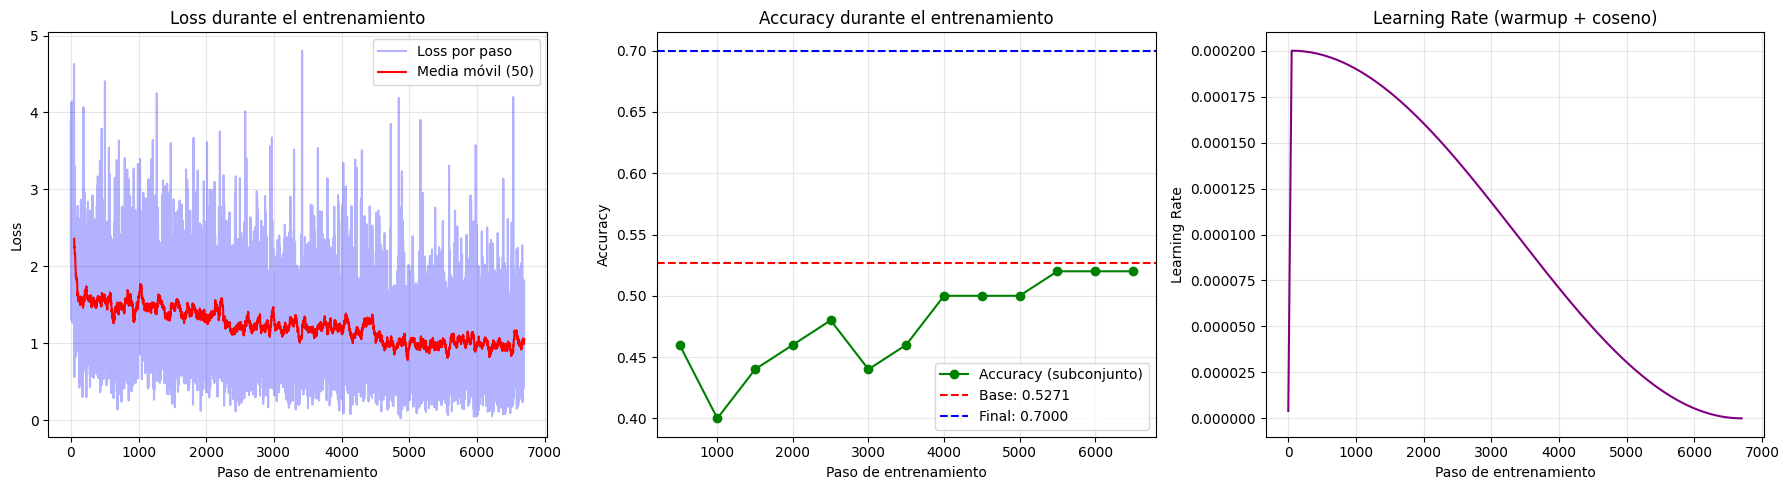

In [21]:
# Gráficas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss de entrenamiento
axes[0].plot(train_losses, alpha=0.3, color="blue", label="Loss por paso")
window = min(50, len(train_losses))
if window > 1:
    smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(train_losses)), smoothed, color="red", label=f"Media móvil ({window})")
axes[0].set_xlabel("Paso de entrenamiento")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss durante el entrenamiento")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy durante entrenamiento
if eval_accuracies:
    axes[1].plot(eval_steps_list, eval_accuracies, "o-", color="green", label="Accuracy (subconjunto)")
    axes[1].axhline(y=base_accuracy, color="red", linestyle="--", label=f"Base: {base_accuracy:.4f}")
    axes[1].axhline(y=finetuned_accuracy, color="blue", linestyle="--", label=f"Final: {finetuned_accuracy:.4f}")
    axes[1].set_xlabel("Paso de entrenamiento")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy durante el entrenamiento")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# 3. Learning rate schedule
axes[2].plot(learning_rates, color="purple")
axes[2].set_xlabel("Paso de entrenamiento")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate (warmup + coseno)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Guardado del Checkpoint

In [1]:
# Guardar checkpoint del modelo fine-tuned (solo pesos LoRA)
checkpoint = {
    "model_state_dict": model_lora.state_dict(),
    "lora_config": lora_config,
    "base_accuracy": base_accuracy,
    "finetuned_accuracy": finetuned_accuracy,
    "hyperparameters": {
        "epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "lora_r": 8,
        "lora_alpha": 16,
    },
}

torch.save(checkpoint, "modelo_finetuned_checkpoint.pt")
print("Checkpoint guardado en: modelo_finetuned_checkpoint.pt")

NameError: name 'model_lora' is not defined